# Homework 1: Part 1

## Name: Terry Cevallos

## 1. Electric circuit dynamics (10 points)

Consider the electric circuit of the figure below. The circuit contains an electromotive force $E$ supplied by a battery, a resistance $R$, an inductor $L$, and a capacitor $C$, in series. If the charge on the capacitor at time $t$ is $Q=Q(t)$, then the current is the rate of change with respect to time, i.e.

$$
I = \frac{dQ}{dt}.
$$

The voltage drops across the resistor, inductor and capacitor are $RI$, $L\frac{dI}{dt}$, and $\frac{Q}{C}$, respectively.

**Kirchhoff's Voltage Law** states that the algebraic sum of the potential differences in any loop must be equal to zero, therefore

$$
L\frac{dI}{dt} + RI + \frac{Q}{C} = E(t).
$$

Since $I=\frac{dQ}{dt}$, the equation becomes

$$
L\frac{d^2Q}{dt^2} + R\frac{dQ}{dt} + \frac{Q}{C}= E(t).
$$

We consider the following parameters:

| Parameter | Value |
|---|---|
| $R$ | $40\,\Omega$ |
| $L$ | $1\,\rm H$ |
| $C$ | $16\times10^{-4}\,\rm F$ |
| $E(t)$ | $100\,\rm V\cos(10\,s^{-1}\,t)$ |
| $t$ | $0\leq t\leq 2\,\rm s$ |

The initial charge and current are both equal to zero:

$$
Q(0)=0, \qquad I(0)=0.
$$

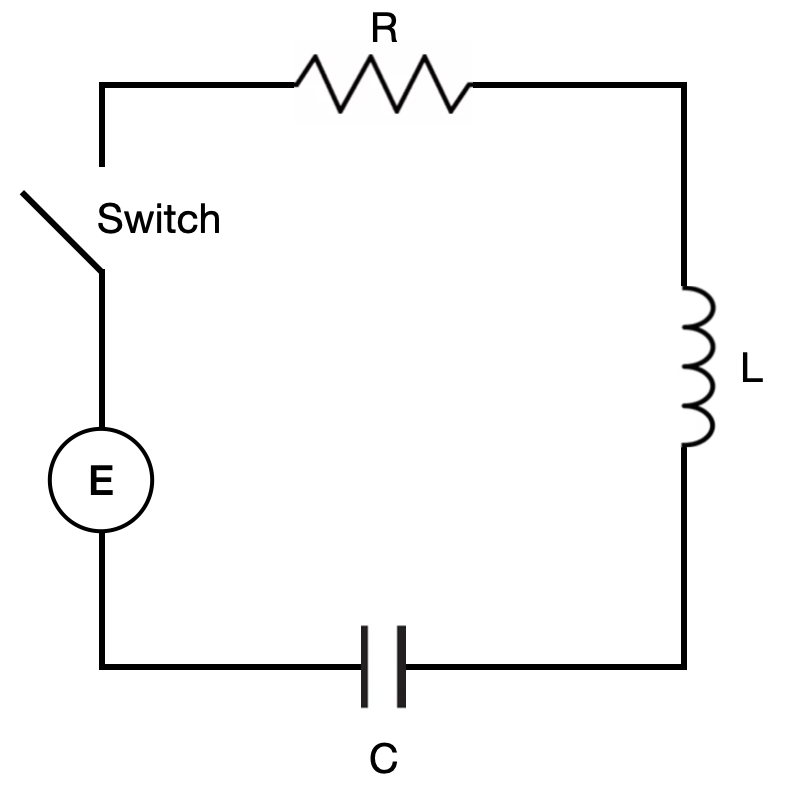

In [1]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy.interactive import printing
from sympy import cos
printing.init_printing(use_latex=True)

### Governing equation

**(a)** Substitute the numerical constants into the circuit equation and write down the resulting **ODE for $Q(t)$**.

In [2]:
# Using sympy to define the variables and the function
t = sp.symbols('t')
Q = sp.Function('Q')(t)


In [3]:
# First define the constants
R = 40 # Resistance in Ohms
L = 1 # Inductance in H
C = 16e-4 # Capacitance in F
E0 = 100 # Voltage amplitude in V

In [4]:
# Define FEM
E_t = E0 * cos(10 * t)

In [5]:
#Now we deffine the derivative of Q with respect to time
dQdt = Q.diff(t)
d2Qdt2 = Q.diff(t, t)
#Checking the derivatives
#display(dQdt)
#display(d2Qdt2)

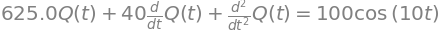

In [6]:
# Differential equation
ode = sp.Eq(L * d2Qdt2 + R * dQdt + Q / C, E_t)
# Checking the equation
display(ode)


### Analytical solution

**(b)** Use **SymPy** to obtain the analytical solution for $Q(t)$ and make a plot of $Q(t)$ vs. $t$ for $0\leq t\leq2$. Does the circuit reach steady state?
The initial charge and current are both equal to zero:

$$
Q(0)=0, \qquad I(0)=0.
$$

#### Reference : https://docs.sympy.org/latest/modules/solvers/ode.html

In [7]:
# Solve the ODE using sympy
ode_solution = sp.dsolve(ode, Q, ics={Q.subs(t, 0): 0, dQdt.subs(t, 0): 0})
# Checking the solution
display(ode_solution)

In [8]:
# Lambdifying expression for numerical evaluation
Q_func = sp.lambdify(t, ode_solution.rhs, 'numpy')
# Checking the lambdified function
#display(Q_func)

In [9]:
# Define time axis for plotting
t_values = np.linspace(0, 2, 500) 
# Evaluate the solution at the defined time points
Q_values = Q_func(t_values)

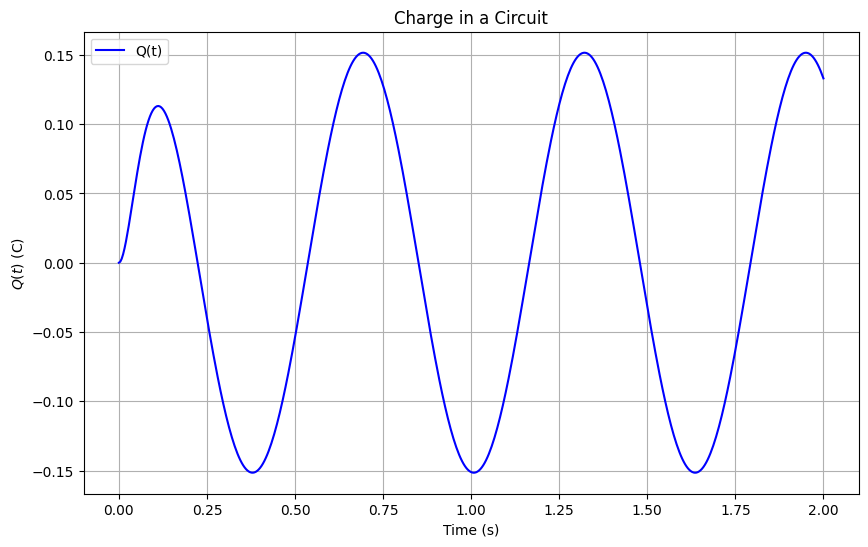

In [10]:
# Plotting the solution
plt.figure(figsize=(10, 6))
plt.plot(t_values, Q_values, label='Q(t)', color='blue')
plt.title('Charge in a Circuit')
plt.xlabel('Time (s)')
plt.ylabel('$Q(t)$ (C)')
plt.grid()
plt.legend()
plt.show()

As can be seen in the plot, the initial oscillation has a peak of approximately 0.11; however, from approximately 0.30 seconds until the end of the time interval, a steady state is reached.

### State vector and slope

**(c)** Reduce the order of the ODE to a system of first-order equations. Write the system in terms of the state vector $S(t)$ and the slope function $F(t,S)$. Implement the slope function in Python.

#### Order reduction

First, we define the state vectors:
$$S(t) = \begin{pmatrix} Q \\ I  \end{pmatrix}$$

We want to find the following expression in first-order matrix form
$$F(t, S) =\frac{dS}{dt} = \mathbf{M} S(t) + \mathbf{E}(t)$$

We define the coefficients of the matrix:
$$\mathbf{M} = \begin{pmatrix} 0 & 1 \\ -\frac{1}{LC} & -\frac{R}{L} \end{pmatrix}$$

and the vector E:
    $$\mathbf{E}(t) = \begin{pmatrix} 0 \\ \frac{E}{L} \end{pmatrix}$$

We finally found the first-order matrix, and it has the following structure:
$$\begin{pmatrix} \dot{Q} \\ \dot{I} \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ -\frac{1}{LC} & -\frac{R}{L} \end{pmatrix} \begin{pmatrix} Q \\ I \end{pmatrix} + \begin{pmatrix} 0 \\ \frac{E}{L} \end{pmatrix}$$

In [11]:
# Create a function slope
def slope_function(S, t, parameters):
    """
    This function helps to get the slope for the system
    Inputs:
        - S: state vector[array]
        - t: time [float]
        - parameters: dictionary with system parameters
    Output:
        - slope: derivative of the state vector [array]
    Author: TPCR
    Date: 09-03-2026
    """
    #Define constants
    R = parameters['R']
    L = parameters['L']
    C = parameters['C']
    E0 = parameters['E0']
    #Define the matrix m
    m = np.array([[0, 1], [-1 / (L * C), -R / L]])
    #Define the vector E_vec
    E_t_val = E0 * np.cos(10 * t) / L
    E_vec = np.array([[0], [E_t_val]])

    slope = m @ S + E_vec
    
    return slope

### Euler integration methods

**(d)** Write down the **explicit Euler** update equation for this system and implement it in Python.

#### Explicit Euler
$$S_{j+1} = S_j + h \cdot F(t_j, S_j)$$

In [12]:
# Implement a function for the explicit Euler method
def euler_explicit(s, t ,h, parameters):
    """
    This fucntion implements the explicit Euler method for solving ODEs.
    Inputs:
        - s: state vector [array]
        - t: time [float]
        - h: step size [float]
        - parameters: dictionary with system parameters
    Output:
        - s_vector: updated state vector [array]
    Author: TPCR
    Date: 09-03-2026
    """
    # Define the explicit Euler method
    s_vector = s + h * slope_function(s, t, parameters)

    return s_vector



**(e)** Write down the **implicit Euler** update equation for this system and implement it in Python.

#### Implicit Euler
$$S_{j+1} = S_j + h \cdot F(t_{j+1}, S_{j+1})$$
$$S_{j+1} = S_j + h \cdot \left( \mathbf{M} S_{j+1} + \mathbf{E}(t_{j+1}) \right)$$


In [13]:
# Implement a function for the implicit Euler method
def euler_implicit(s, t_c, t_n ,h, parameters):
    """
    This fucntion implements the implicit Euler method for solving ODEs.
    Inputs:
        - s: state vector [array]
        - t_c: current time [float]
        - t_n: next time [float]
        - h: step size [float]
        - parameters: dictionary with system parameters
    Output:
        - s_vector: updated state vector [array]
    Author: TPCR
    Date: 09-03-2026
    """
    # Predict step
    predicted_s = s + h * slope_function(s, t_c, parameters)
    # Correct step
    s_vector = s + h * slope_function(predicted_s, t_n, parameters)
    
    return s_vector


**(f)** Write down the **trapezoidal Euler** update equation for this system and implement it in Python.

#### Trapezoidal Method
$$ S_{j+1} = S_j + \frac{h}{2} \left[ F(t_j, S_j) + F(t_{j+1}, {S}_{j+1}) \right] $$

$$ S_{j+1} = S_j + \frac{h}{2} \left[ (\mathbf{M} S_j + \mathbf{E}(t_j)) + (\mathbf{M} {S}_{j+1} + \mathbf{E}(t_{j+1})) \right] $$



In [14]:
# Implement a function for the trapezoidal Euler method
def trapezoidal(s ,t_c, t_n , h , parameters):
    """
    This fucntion implements the trapezoidal method for solving ODEs.
    Inputs:
        - s: state vector [array]
        - t_c: current time [float]
        - t_n: next time [float]
        - h: step size [float]
        - parameters: dictionary with system parameters
    Output:
        - s_vector: updated state vector [array]
    Author: TPCR
    Date: 10-03-2026
    """
    # Define current slope
    slope_current = slope_function(s, t_c, parameters)
    # Define the predicted step
    predicted_s = s + h * slope_current
    # Define the slope at the predicted
    slope_predicted = slope_function(predicted_s, t_n, parameters)
    # Get the state vector
    s_vector = s + (h / 2) * (slope_current + slope_predicted)   
    
    return s_vector

### Settings and initial conditions

**(g)** Create a dictionary that allocates all the user-defined parameters needed for integration. Include the circuit parameters, the initial conditions, the time interval, the time step size, and an option to select the integration method.

In [15]:
# Dictionary to store the parameters 
parameters = {
            # Circuit parameters
            'R': 40.0,
            'L': 1.0,
            'C': 16e-4,
            'E0': 100.0,   
            
            # Initial conditions [Q0, I0]
            'S0': np.array([[0.0], [0.0]]),
            
            # Interval and step size for integration
            't_start': 0.0,
            't_end': 2.0,
            'h': 0.01,
            
            # Methods
            'method': ['explicit_euler', 'implicit_euler', 'trapezoidal'],
            'colors': {'explicit_euler': 'brown', 'implicit_euler': 'orange', 'trapezoidal': 'blue'},
            'styles': {'explicit_euler': '--', 'implicit_euler': '-.', 'trapezoidal': '-'},

            }


### Time stepping

**(h)** Create a Python function that integrates the system of ODEs using the settings and initial conditions as arguments. The function should return the times ($t$) and the system state $S(t)$.

In [16]:
def integrate_system(parameters, method):
    """
    This function integrates the system using the specified method
    Inputs:
        - parameters: dictionary with system parameters
        - method: the method to use ['explicit_euler', 'implicit_euler', 'trapezoidal']
    Output:
        - t_vector: time vector [array]
        - s_vector: state vector [array]
    Author: TPCR
    Date: 10-03-2026
    """
    # Define the time vector
    t_start = parameters['t_start']
    t_end = parameters['t_end']
    h = parameters['h']
    t_vector = np.arange(t_start, t_end + h, h)
    #Define the state vector
    s_vector = np.zeros((len(t_vector), 2, 1))
    s_vector[0] = parameters['S0']

    # Crerate a loop to integrate the system
    for i in range(0, len(t_vector) - 1):
        t_c = t_vector[i]
        t_n = t_vector[i + 1]
        s_c = s_vector[i]         
   
        # Integrate using the specified method
        if method == 'explicit_euler':
            s_vector[i + 1] = euler_explicit(s_c, t_c, h, parameters)
        elif method == 'implicit_euler':
            s_vector[i + 1] = euler_implicit(s_c, t_c, t_n, h, parameters)
        elif method == 'trapezoidal':
            s_vector[i + 1] = trapezoidal(s_c, t_c, t_n, h, parameters)
        else:
            print("Invalid method.")

    return t_vector, s_vector

### Plotting

**(i)** Create a Python function that plots $Q(t)$ vs. $t$ comparing the numerical solutions with the analytical solution.

In [17]:
# Function to plot the results
def plot_results(parameters, q_analitic_func):
    """
    This function plots the results of the numerical integration 
    and compares them with the analytical solution.
    Inputs:
        - parameters: dictionary with system parameters
        - q_analitic_func: gives the analytical solution for Q(t)
    Output:
        - Plots
    Author: TPCR
    Date: 11-03-2026
    """
    plt.figure(figsize=(12, 8))  
   
    t_exp, s_exp = integrate_system(parameters, 'explicit_euler' )
    q_exp = s_exp[:, 0, 0]
    plt.plot(t_exp, q_exp, label='Explicit Euler', color=parameters['colors']['explicit_euler'],linewidth=2, linestyle='--')

    
    t_imp, s_imp = integrate_system(parameters, 'implicit_euler')
    q_imp = s_imp[:, 0, 0]
    plt.plot(t_imp, q_imp, label='Implicit Euler', color=parameters['colors']['implicit_euler'],linewidth=2, linestyle=':')


    t_trap, s_trap = integrate_system(parameters, 'trapezoidal')
    q_trap = s_trap[:, 0, 0]
    plt.plot(t_trap, q_trap, label='Trapezoidal', color=parameters['colors']['trapezoidal'], linewidth=2,linestyle='-')

  
    q_exacta = q_analitic_func(t_trap)
    plt.plot(t_trap, q_exacta, label='Analytical', color='red', linewidth=2, linestyle='--')

    plt.title('Comparing Numerical Solutions')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('$Q(t)$ (C)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

### Simulation

**(j)** Run the simulation using the three Euler methods and compare the numerical solutions with the analytical solution. Which method produces the best results?

In [18]:
# Lambdifying expression for numerical evaluation
Q_func = sp.lambdify(t, ode_solution.rhs, 'numpy')
# Checking the lambdified function
#display(Q_func)
# Define time axis for plotting
t_values = np.linspace(0, 2, 1000) 
# Evaluate the solution at the defined time points
Q_values = Q_func(t_values)

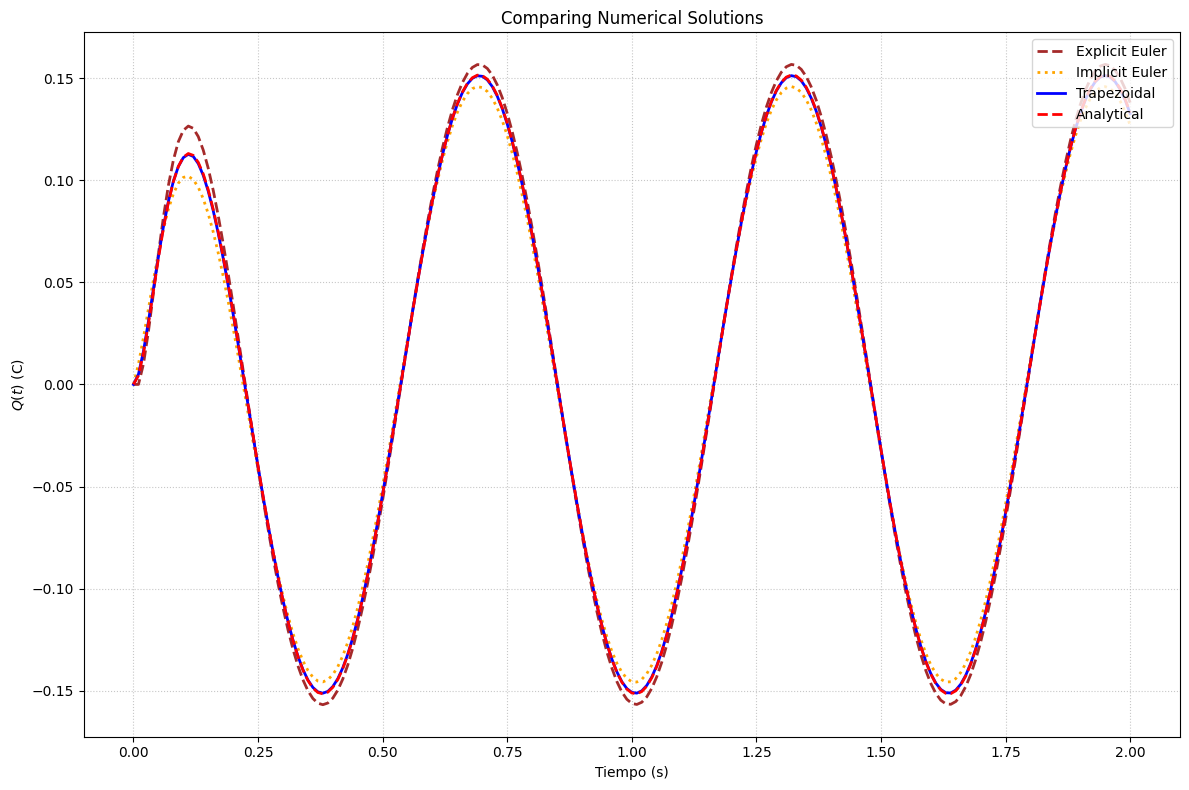

In [19]:
# Call the function to plot the results
plot_results(parameters, Q_func)

As can be seen in the plot, the best method for approximating the result is the trapezoidal method, since it has second-order accuracy.